In [1]:
import os
import cv2
from time import time
import numpy as np
from sklearn.utils import shuffle

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 6]

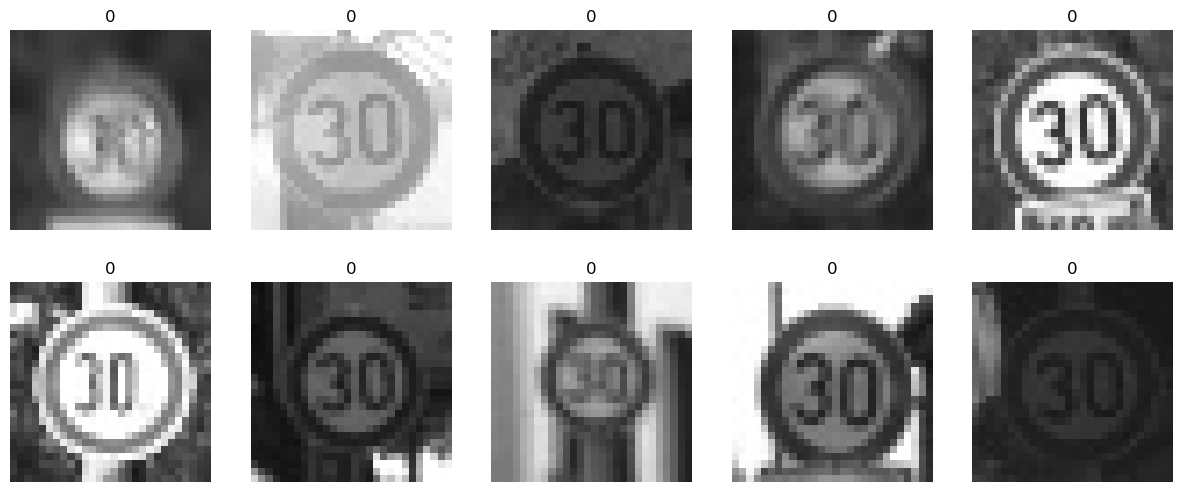

In [2]:
folder = 'data/subset_homework'

# Load traffic sign class 0
fnames_0 = os.listdir(os.path.join(folder, 'class_id_0'))
images_0 = [cv2.imread(os.path.join(folder, 'class_id_0', f), cv2.IMREAD_UNCHANGED) for f in fnames_0]
labels_0 = [0] * len(images_0)

for cnt, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_0[idx]), plt.axis(False)

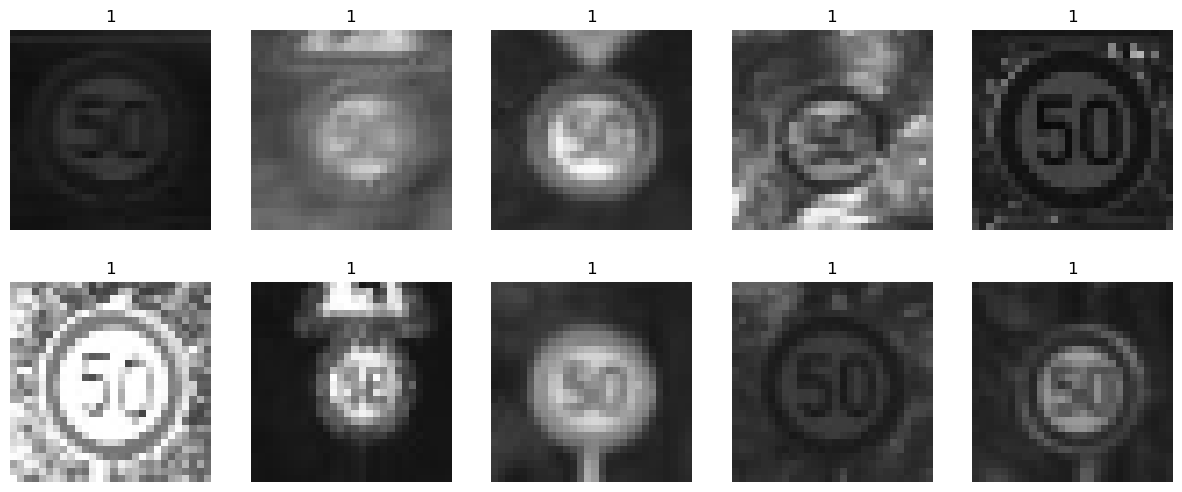

In [3]:
# Load traffic sign class 1
fnames_1 = os.listdir(os.path.join(folder, 'class_id_1'))
images_1 = [cv2.imread(os.path.join(folder, 'class_id_1', f), cv2.IMREAD_UNCHANGED) for f in fnames_1]
labels_1 = [1] * len(images_1)

for cnt, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_1[idx]), plt.axis(False)

In [4]:
print('Num samples class_0', len(images_0))
print('Num samples class_1', len(images_1))

Num samples class_0 2220
Num samples class_1 2250


In [5]:
# Put both classes together and shuffle the data
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

print('Images', images.shape)
print('Labels', labels.shape)

Images (4470, 28, 28)
Labels (4470,)


In [6]:
pixels = np.array([image.flatten() for image in images])/255

print('Shape', pixels.shape)

Shape (4470, 784)


In [7]:
import tensorflow as tf

Model = tf.keras.Model
Dense = tf.keras.layers.Dense
Input = tf.keras.layers.Input

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

2026-05-14 13:09:05.001552: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Literally, a grid search

In [8]:
X_train, X_test, y_train, y_test = train_test_split(pixels, labels, test_size=0.2, random_state=42)

activations = ["linear", "relu", "tanh", "sigmoid"]
neurons_list = [1, 4, 8]
num_layers_list = [1, 2, 3]

results = []

for activation in activations:
    for neurons in neurons_list:
        for num_layers in num_layers_list:

            inputs = Input(shape=(X_train.shape[1],))

            x = inputs

            for _ in range(num_layers):
                x = Dense(neurons, activation=activation)(x)

            outputs = Dense(1, activation="sigmoid")(x)

            model = Model(inputs, outputs)

            model.compile(
                optimizer="adam",
                loss="binary_crossentropy",
                metrics=["accuracy"]
            )

            history = model.fit(
                X_train,
                y_train,
                epochs=10,
                batch_size=32,
                verbose=0
            )

            test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
            train_acc = history.history["accuracy"][-1]

            results.append({
                "activation": activation,
                "neurons": neurons,
                "layers": num_layers,
                "train_accuracy": train_acc,
                "test_accuracy": test_acc
            })

            print(
                f"activation={activation:7s} "
                f"neurons={neurons:2d} "
                f"layers={num_layers} | "
                f"train_acc={train_acc:.4f} "
                f"test_acc={test_acc:.4f}"
            )

Starting grid search with test set evaluation...

activation=linear  neurons= 1 layers=1 | train_acc=0.9016 test_acc=0.8714
activation=linear  neurons= 1 layers=2 | train_acc=0.8990 test_acc=0.8770
activation=linear  neurons= 1 layers=3 | train_acc=0.9304 test_acc=0.9228
activation=linear  neurons= 4 layers=1 | train_acc=0.9192 test_acc=0.8949
activation=linear  neurons= 4 layers=2 | train_acc=0.9315 test_acc=0.9284
activation=linear  neurons= 4 layers=3 | train_acc=0.9396 test_acc=0.9217
activation=linear  neurons= 8 layers=1 | train_acc=0.9382 test_acc=0.9239
activation=linear  neurons= 8 layers=2 | train_acc=0.9385 test_acc=0.9508
activation=linear  neurons= 8 layers=3 | train_acc=0.9298 test_acc=0.9474
activation=relu    neurons= 1 layers=1 | train_acc=0.5076 test_acc=0.4866
activation=relu    neurons= 1 layers=2 | train_acc=0.5076 test_acc=0.4866
activation=relu    neurons= 1 layers=3 | train_acc=0.5076 test_acc=0.4866
activation=relu    neurons= 4 layers=1 | train_acc=0.5076 test